# Task 3 — Notebook 01: Pixel panel (SMAP + CDL, multi-event)

**NAFSI Task 3** uses **processed weekly SMAP Parquet** (`data/processed/smap/smap_weekly_{year}_wide.parquet`) — **no interim NetCDF**.

Spatial subset: **Task 2 rotation-eligible pixels** (`data/processed/task2/rotation_metrics.parquet`, ~2.08M `iy, ix`) so joins stay tractable and align with rotation analysis.

Per-event CDL labels are attached from the **event year** (e.g. `cdl_2019` for the 2019 flood, `cdl_2022` for the 2022 drought) so crop-stratified tables use the actual land cover of the event year.

**Outputs:** `data/processed/task3/task3_pixel_panel.parquet` (`iy`, `ix`, `cdl_label`) + sanity histograms for each event year.


Event years: [2019, 2022]
Wrote data\processed\task3\task3_pixel_panel.parquet rows 2084112


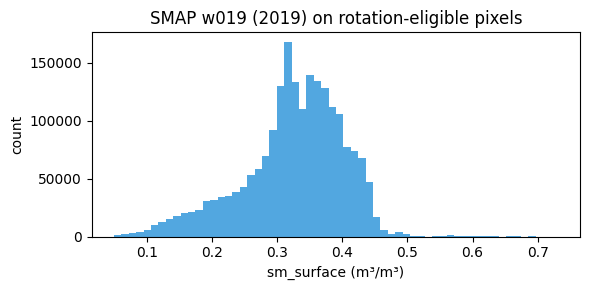

Saved artifacts\figures\task3\task3__smap_week_histogram_subset_2019.png


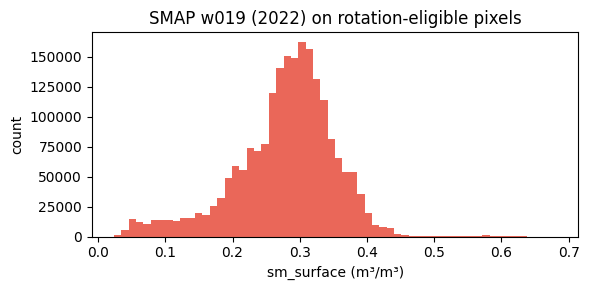

Saved artifacts\figures\task3\task3__smap_week_histogram_subset_2022.png


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml

_cwd = Path.cwd().resolve()
REPO_ROOT = next((p for p in (_cwd, *_cwd.parents) if (p / "requirements.txt").is_file() and (p / "src").is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError("Repo root not found")
sys.path.insert(0, str(REPO_ROOT))

from src.io.smap_weekly_parquet import smap_wide_parquet_path
from src.modeling.task3_smap_anomalies import (
    attach_cdl_year,
    event_windows_from_cfg,
    load_rotation_eligible_pixels,
)

with open(REPO_ROOT / "configs" / "task3_soil_moisture.yaml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

events = event_windows_from_cfg(cfg)
event_years = sorted({int(ev["year"]) for ev in events})
print("Event years:", event_years)

out_dir = REPO_ROOT / cfg["output"]["processed_dir"]
out_dir.mkdir(parents=True, exist_ok=True)
fig_dir = REPO_ROOT / cfg["output"]["figures_dir"]
fig_dir.mkdir(parents=True, exist_ok=True)

pixels = load_rotation_eligible_pixels(REPO_ROOT)

# Attach CDL from the first event year as default cdl_label (NB02 re-attaches per-event)
panel = attach_cdl_year(REPO_ROOT, pixels, event_years[0])
out_pq = out_dir / "task3_pixel_panel.parquet"
panel.to_parquet(out_pq, index=False)
print("Wrote", out_pq.relative_to(REPO_ROOT), "rows", len(panel))

# Sanity histograms — one sample week per event year
colors = ["#3498db", "#e74c3c", "#2ecc71", "#9b59b6", "#f39c12"]
for i, y in enumerate(event_years):
    wcol = "w019"
    path = smap_wide_parquet_path(REPO_ROOT, y)
    sm = (
        pd.read_parquet(path, columns=["iy", "ix", wcol])
        .merge(panel[["iy", "ix"]], on=["iy", "ix"], how="inner")[wcol]
        .astype("float32")
    )
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.hist(sm.dropna().to_numpy(), bins=60, color=colors[i % len(colors)], alpha=0.85)
    ax.set_title(f"SMAP {wcol} ({y}) on rotation-eligible pixels")
    ax.set_xlabel("sm_surface (m³/m³)")
    ax.set_ylabel("count")
    fig.tight_layout()
    fname = f"task3__smap_week_histogram_subset_{y}.png"
    fig.savefig(fig_dir / fname, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved", (fig_dir / fname).relative_to(REPO_ROOT))
